<a href="https://colab.research.google.com/github/AzizulHakim00/MAT-Appendix/blob/multimodal-data-loader/MAT_Appendix_CGR_MAT_Multimodal_Training_v1_5_AUTO_RUNTIME.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CGR-MAT v1.5 — Adaptive Runtime + Linkage-Fixed Pipeline

This notebook does **not crash when a GPU is unavailable**. It automatically chooses:

- **full** scientific mode when CUDA/T4 is available;
- **smoke** structural-validation mode on CPU, clearly labelled as non-scientific.

It preserves the verified linkage cohort: 463 confirmed labelled appendicitis patients, 445 raw-ultrasound-linked patients, and 18 labelled cases without usable `US_Number`. All artifacts are saved to Google Drive.


In [3]:
!pip -q install catboost==1.2.8 openpyxl==3.1.5 requests


In [4]:
from pathlib import Path
from google.colab import drive

MOUNT = Path('/content/drive')
DRIVE_ROOT = MOUNT / 'MyDrive'
if not DRIVE_ROOT.exists():
    try:
        drive.mount(str(MOUNT), force_remount=False, timeout_ms=120000)
    except Exception as first_error:
        print('First Drive mount attempt failed:', first_error)
        try:
            drive.flush_and_unmount()
        except Exception:
            pass
        drive.mount(str(MOUNT), force_remount=True, timeout_ms=120000)
if not DRIVE_ROOT.exists():
    raise RuntimeError('Google Drive is required so checkpoints are not lost. Enable pop-ups/cookies and rerun this cell.')
print('✓ Google Drive is ready:', DRIVE_ROOT)


Mounted at /content/drive
✓ Google Drive is ready: /content/drive/MyDrive


In [5]:
import hashlib
import pandas as pd
import requests
from IPython.display import display

CACHE = DRIVE_ROOT / 'MAT-Appendix' / 'data_cache' / 'regensburg'
CACHE.mkdir(parents=True, exist_ok=True)
XLSX = CACHE / 'app_data.xlsx'
URL = 'https://zenodo.org/records/7711412/files/app_data.xlsx?download=1'
EXPECTED_MD5 = 'd17a803f5e27532e518676a38f588b59'

def md5(path):
    h = hashlib.md5()
    with path.open('rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()

if not XLSX.exists() or md5(XLSX) != EXPECTED_MD5:
    print('Downloading official app_data.xlsx for preflight...')
    response = requests.get(URL, timeout=180)
    response.raise_for_status()
    XLSX.write_bytes(response.content)
if md5(XLSX) != EXPECTED_MD5:
    raise RuntimeError('Official app_data.xlsx checksum mismatch.')

df = pd.read_excel(XLSX, engine='openpyxl')
norm = lambda s: s.fillna('').astype(str).str.strip().str.lower().str.replace('_', ' ', regex=False)
diagnosis = norm(df['Diagnosis'])
severity = norm(df['Severity'])
confirmed = diagnosis.eq('appendicitis') & severity.isin({'complicated', 'uncomplicated'})
audit = df.loc[confirmed, ['US_Number', 'Diagnosis', 'Severity']].copy()
audit['target'] = severity.loc[audit.index].map({'uncomplicated': 0, 'complicated': 1}).astype(int)
audit['us_number_numeric'] = pd.to_numeric(audit['US_Number'], errors='coerce')
linked = audit.loc[audit['us_number_numeric'].notna()]
unlinked = audit.loc[audit['us_number_numeric'].isna()]
table = pd.DataFrame([
    {'group': 'all_confirmed_appendicitis_with_observed_severity', 'patients': len(audit), 'complicated': int(audit.target.sum()), 'uncomplicated': int((audit.target == 0).sum())},
    {'group': 'multimodal_linked_confirmed_appendicitis', 'patients': len(linked), 'complicated': int(linked.target.sum()), 'uncomplicated': int((linked.target == 0).sum())},
    {'group': 'confirmed_appendicitis_without_us_number', 'patients': len(unlinked), 'complicated': int(unlinked.target.sum()), 'uncomplicated': int((unlinked.target == 0).sum())},
])
print('SCHEMA PREFLIGHT — MUST PASS BEFORE TRAINING')
display(table)
expected = [(463, 118, 345), (445, 116, 329), (18, 2, 16)]
actual = [tuple(map(int, row)) for row in table[['patients', 'complicated', 'uncomplicated']].to_numpy()]
if actual != expected:
    raise RuntimeError(f'Schema preflight failed. Expected {expected}, found {actual}.')
print('✓ Schema preflight passed.')


SCHEMA PREFLIGHT — MUST PASS BEFORE TRAINING


,group,patients,complicated,uncomplicated
0,all_confirmed_appendicitis_with_observed_severity,463,118,345
1,multimodal_linked_confirmed_appendicitis,445,116,329
2,confirmed_appendicitis_without_us_number,18,2,16


✓ Schema preflight passed.


In [6]:
import json
import os
import torch
from datetime import datetime, timezone

HAS_GPU = torch.cuda.is_available()
REQUESTED_MODE = os.environ.get('CGR_MAT_REQUESTED_MODE', 'auto').strip().lower()
if REQUESTED_MODE not in {'auto', 'full', 'quick', 'smoke'}:
    raise ValueError('CGR_MAT_REQUESTED_MODE must be auto, full, quick, or smoke.')

if REQUESTED_MODE == 'auto':
    SELECTED_MODE = 'full' if HAS_GPU else 'smoke'
elif REQUESTED_MODE == 'full' and not HAS_GPU:
    print('⚠ Full mode requested but no CUDA GPU is attached. Falling back to smoke mode instead of crashing.')
    SELECTED_MODE = 'smoke'
else:
    SELECTED_MODE = REQUESTED_MODE

os.environ['CGR_MAT_RUN_MODE'] = SELECTED_MODE
os.environ['CGR_MAT_USE_DRIVE'] = '1'
os.environ['CGR_MAT_FORCE_RESTART'] = '0'
os.environ['CGR_MAT_PRETRAINED'] = '1' if HAS_GPU else '0'

decision = {
    'timestamp_utc': datetime.now(timezone.utc).isoformat(),
    'cuda_available': HAS_GPU,
    'gpu_name': torch.cuda.get_device_name(0) if HAS_GPU else None,
    'requested_mode': REQUESTED_MODE,
    'selected_mode': SELECTED_MODE,
    'scientific_result': bool(HAS_GPU and SELECTED_MODE == 'full'),
}
runtime_file = DRIVE_ROOT / 'MAT-Appendix' / 'runtime_decision_v1_5.json'
runtime_file.parent.mkdir(parents=True, exist_ok=True)
runtime_file.write_text(json.dumps(decision, indent=2), encoding='utf-8')
print(json.dumps(decision, indent=2))
if SELECTED_MODE == 'smoke':
    print('⚠ CPU smoke mode validates the complete pipeline and artifact exports, but its metrics are NOT paper results.')
else:
    print('✓ Scientific GPU run selected.')


{
  "timestamp_utc": "2026-08-02T14:34:42.950086+00:00",
  "cuda_available": false,
  "gpu_name": null,
  "requested_mode": "auto",
  "selected_mode": "smoke",
  "scientific_result": false
}
⚠ CPU smoke mode validates the complete pipeline and artifact exports, but its metrics are NOT paper results.


Loading pinned linkage-fixed CGR-MAT loader...
Source commit: a072de95190d214177bbf3091cf98ab982e9ce5e
Loader SHA256: 47185e7e03400781587c97981bb8c7e4b2d2a3aed829eddbca1c4eb08136cc77
Loading checksum-pinned CGR-MAT v1.4 source parts...
Source commit: a072de95190d214177bbf3091cf98ab982e9ce5e
  ✓ part 1/6 verified: cgr_mat_multimodal_pipeline.py.part01
  ✓ part 2/6 verified: cgr_mat_multimodal_pipeline.py.part02
  ✓ part 3/6 verified: cgr_mat_multimodal_pipeline.py.part03
  ✓ part 4/6 verified: cgr_mat_multimodal_pipeline.py.part04
  ✓ part 5/6 verified: cgr_mat_multimodal_pipeline.py.part05
  ✓ part 6/6 verified: cgr_mat_multimodal_pipeline.py.part06
  ✓ safety patch applied: version label
  ✓ safety patch applied: source-aware v1.4 run identity
  ✓ safety patch applied: Peritonitis leakage exclusion
  ✓ safety patch applied: correct image-linkage cohort audit
  ✓ safety patch applied: correct multimodal and tabular cohort signatures
  ✓ safety patch applied: cohort audit metadata
  ✓ s

,group,patients,complicated,uncomplicated
0,all_confirmed_appendicitis_with_observed_severity,463,118,345
1,multimodal_linked_confirmed_appendicitis,445,116,329
2,confirmed_appendicitis_without_us_number,18,2,16


Note: 18 confirmed appendicitis cases have observed severity labels but no usable US_Number. They are retained in the tabular audit and excluded only from the raw-ultrasound multimodal cohort because image linkage is impossible.


Auditing ultrasound images:   0%|          | 0/2097 [00:00<?, ?it/s]


DATASET AUDIT


...

,split,patients,complicated,uncomplicated,with_images
0,development,403,103,300,340
1,official_holdout,42,13,29,42



CGR-MAT MULTIMODAL SEVERITY PIPELINE
Patient-level official holdout + leakage-safe development CV

------------------------------------------------------------------------------------
OUTER FOLD 1/2
------------------------------------------------------------------------------------


cgr_mat_pipeline_v1_4@a072de95190d214177bbf3091cf98ab982e9ce5e:751: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True


Fold 1 epoch selection 1/1:   0%|          | 0/84 [00:00<?, ?it/s]

Fold 1 | epoch 01 | monitor only | loss 0.7977 | ROC 0.9250 | PR 0.8090


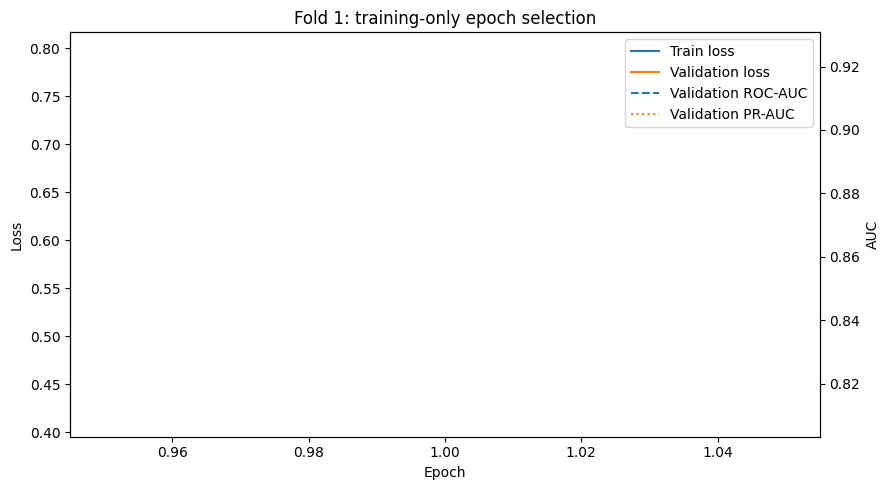

cgr_mat_pipeline_v1_4@a072de95190d214177bbf3091cf98ab982e9ce5e:751: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True


Fold 1 honest refit 1/1:   0%|          | 0/101 [00:00<?, ?it/s]

Fold 1 honest refit | epoch 01 | train loss 0.7987
Fold result:


,threshold,accuracy,balanced_accuracy,precision,sensitivity,specificity,npv,f1,f2,mcc,...,pr_auc,brier,log_loss,tn,fp,fn,tp,fold,n_validation,best_epoch
0,0.5,0.787129,0.793846,0.56,0.807692,0.78,0.92126,0.661417,0.742049,0.53182,...,0.660103,0.150778,0.465985,117,33,10,42,1,202,1



------------------------------------------------------------------------------------
OUTER FOLD 2/2
------------------------------------------------------------------------------------


cgr_mat_pipeline_v1_4@a072de95190d214177bbf3091cf98ab982e9ce5e:751: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True


Fold 2 epoch selection 1/1:   0%|          | 0/85 [00:00<?, ?it/s]

Fold 2 | epoch 01 | monitor only | loss 0.8026 | ROC 0.6600 | PR 0.5236


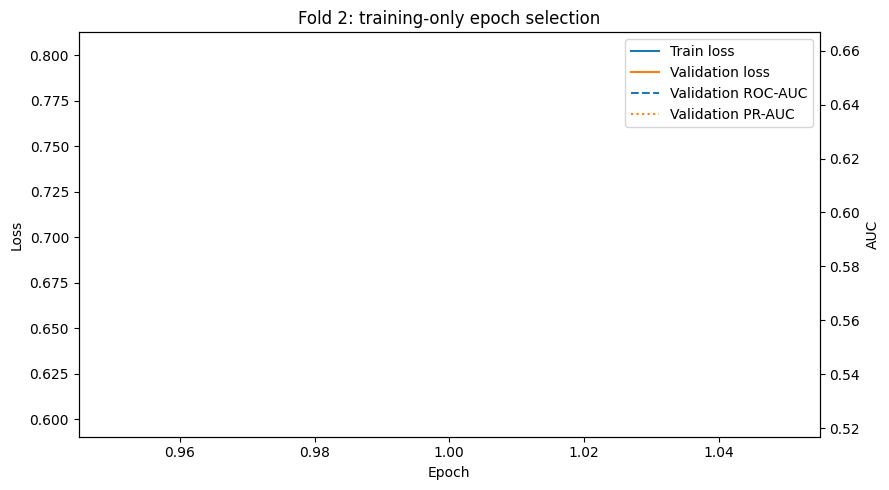

cgr_mat_pipeline_v1_4@a072de95190d214177bbf3091cf98ab982e9ce5e:751: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True


Fold 2 honest refit 1/1:   0%|          | 0/101 [00:00<?, ?it/s]

Fold 2 honest refit | epoch 01 | train loss 0.8408
Fold result:


,threshold,accuracy,balanced_accuracy,precision,sensitivity,specificity,npv,f1,f2,mcc,...,pr_auc,brier,log_loss,tn,fp,fn,tp,fold,n_validation,best_epoch
0,0.5,0.800995,0.79549,0.57971,0.784314,0.806667,0.916667,0.666667,0.732601,0.541617,...,0.754606,0.140967,0.441884,121,29,11,40,2,201,1



REPEATED-FREE OUTER CV SUMMARY (one prespecified 5-fold run)


...

Final model | epoch 02 | train loss 0.7258


Final model epoch 3/4:   0%|          | 0/202 [00:00<?, ?it/s]

Final model | epoch 03 | train loss 0.7192


Final model epoch 4/4:   0%|          | 0/202 [00:00<?, ?it/s]

Final model | epoch 04 | train loss 0.6758


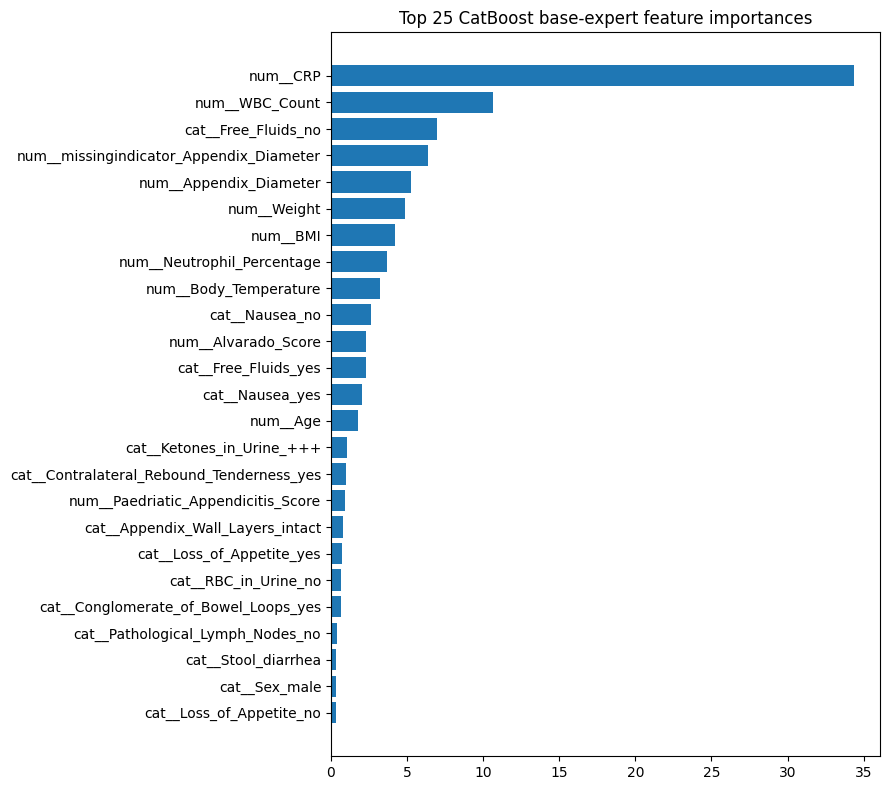


OFFICIAL HOLDOUT RESULTS


,model,threshold,accuracy,balanced_accuracy,precision,sensitivity,specificity,npv,f1,f2,mcc,roc_auc,pr_auc,brier,log_loss,tn,fp,fn,tp
0,Tabular CatBoost base,0.500,0.761905,0.721485,0.615385,0.615385,0.827586,0.827586,0.615385,0.615385,0.442971,0.838196,0.645155,0.158545,0.482629,24,5,5,8
1,"CGR-MAT calibrated, threshold 0.5",0.500,0.809524,0.777188,0.692308,0.692308,0.862069,0.862069,0.692308,0.692308,0.554377,0.846154,0.658059,0.163746,0.573667,25,4,4,9
2,"CGR-MAT calibrated, OOF-selected threshold",0.384,0.761905,0.742706,0.600000,0.692308,0.793103,0.851852,0.642857,0.671642,0.468331,0.846154,0.658059,0.163746,0.573667,23,6,4,9


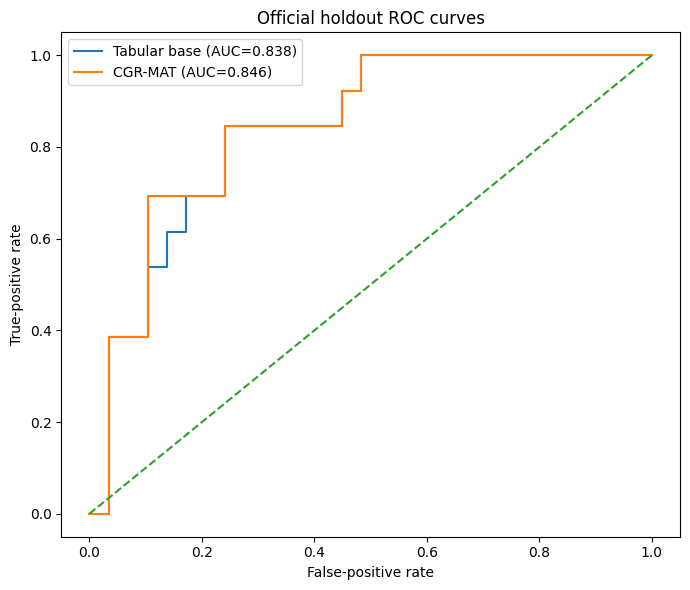

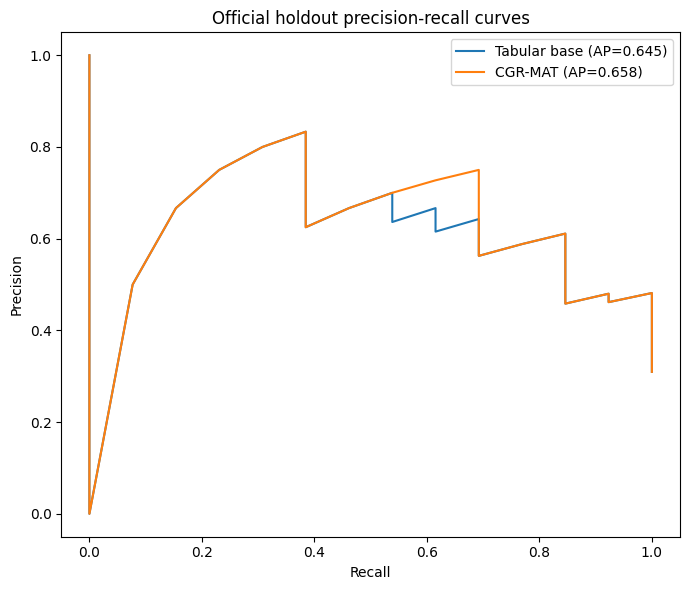

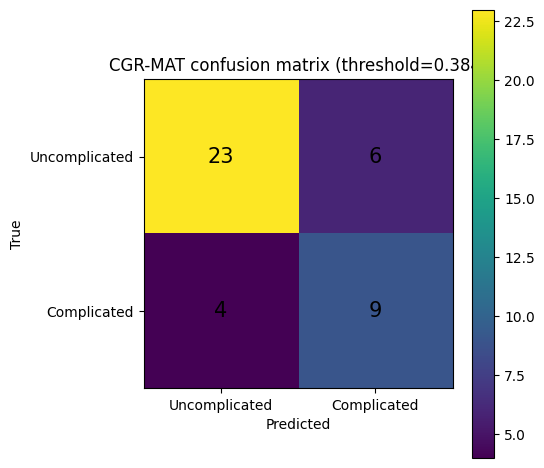

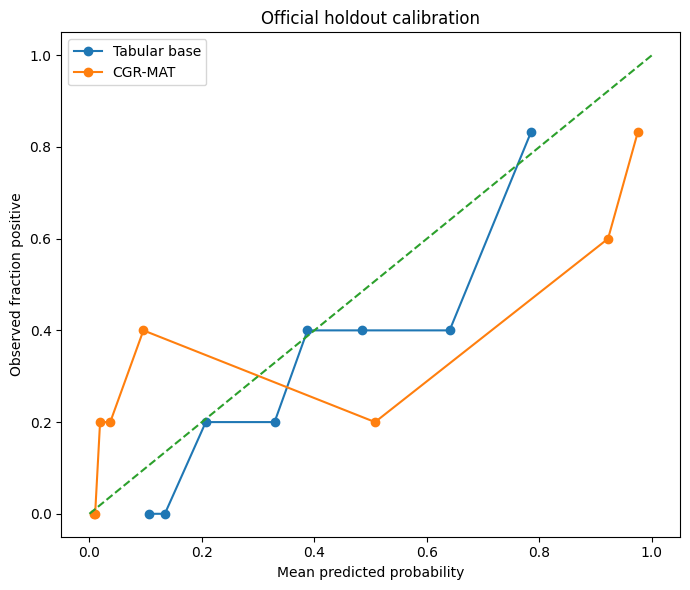


PIPELINE COMPLETE
Results directory: /content/drive/MyDrive/MAT-Appendix/cgr_mat_runs/cgr_mat_v1_4_smoke_118932775153
Downloadable ZIP:  /content/drive/MyDrive/MAT-Appendix/cgr_mat_runs/cgr_mat_v1_4_smoke_118932775153.zip
Saved: .pt, .pkl, .cbm, .csv, .json and publication-quality .png files
Primary scientific result is the untouched official holdout table above.


In [7]:
import hashlib
import urllib.request

SOURCE_COMMIT = 'a072de95190d214177bbf3091cf98ab982e9ce5e'
LOADER_URL = (
    'https://raw.githubusercontent.com/AzizulHakim00/MAT-Appendix/'
    f'{SOURCE_COMMIT}/src/cgr_mat/cgr_mat_verified_loader_v1_4.py'
)
print('Loading pinned linkage-fixed CGR-MAT loader...')
print('Source commit:', SOURCE_COMMIT)
loader_bytes = urllib.request.urlopen(LOADER_URL, timeout=120).read()
print('Loader SHA256:', hashlib.sha256(loader_bytes).hexdigest())
loader = loader_bytes.decode('utf-8')
exec(compile(loader, LOADER_URL, 'exec'), globals(), globals())


## Interpretation

A **full GPU run** is the scientific experiment. A **CPU smoke run** only proves that data loading, model construction, training loops, saving, tables and figures execute without a GPU; do not report smoke metrics in a paper.

All outputs are stored under `MyDrive/MAT-Appendix/cgr_mat_runs/`. Reopen the notebook later with a GPU and use Run all; the source-aware run directory will be different from the CPU smoke directory.
